# Spectral Graph Convolutions and Classification

![Lap](./Laplacian.png)

## IntroductionThis project explores how to explore how to combine classical spectral graph theory with modern Graph Neural Networks (GNNs) to perform signal processing and semi‐supervised learning on graph‐structured data.  Specifically, this includes:1. **Derive & implement** the spectral convolution theorem using the normalized graph Laplacian.  2. **Incorporate** a Laplacian‐smoothing regularization term into a two‐layer GCN training loop.  3. **Demonstrate** how this regularizer denoises noisy graph signals by visualizing before/after results.### Straight Forward Explanation of this partImagine you have dots connected by lines (a graph), and you teach a little network to make each dot’s number smooth—meaning neighbors get similar numbers—while also learning to sort the whole graph into categories. You compute a special “Laplacian” matrix from the lines that measures differences between neighbors. During training, you add a penalty that says “if connected dots have very different numbers, pay extra cost.” Early on that cost drops (dots become more alike), but if you over-penalize it, the network forgets how to tell classes apart. The trick is finding just the right balance so neighbors are smooth without losing the differences you need for correct classification.### Learning OutcomesBy the end of this project, you will be able to:- Compute the **unnormalized** and **normalized** Laplacian matrices from an adjacency matrix.  - Perform **eigen‐decomposition** of the Laplacian and implement spectral filtering of graph signals.  - Integrate a **trace‐based regularization** term, $\mathrm{Tr}(H^\top L H)$, into your GCN loss function.  - Visualize and quantitatively evaluate how Laplacian regularization removes high-frequency noise.  - Write clear, well‐documented PyTorch Geometric code that bridges theory and practice.

In [ ]:
# Setup Environment!pip install torch_geometric  # PyTorch Geometric :contentReference[oaicite:0]{index=0}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.3 MB/s eta 0:00:00


In [ ]:
# Required librariesimport numpy as npimport scipy.sparse.linalg as splaimport networkx as nximport torchimport torch.nn.functional as Ffrom torch_geometric.nn import GCNConvfrom torch_geometric.data import Data, DataLoaderimport matplotlib.pyplot as pltfrom matplotlib.animation import FuncAnimationimport torch.nn.functional as Ffrom torch_geometric.datasets import TUDataset   # MUTAG dataset :contentReference[oaicite:3]{index=3}from torch_geometric.loader  import DataLoaderfrom torch_geometric.nn      import GCNConv, global_mean_poolfrom torch_geometric.utils   import to_networkx

## Experiment 1: Filtering SignalsBefore you begin this task you should read this [article](https://medium.com/@n.rajadhyaksha/a-gentle-introduction-to-graph-spectral-filtering-df03ddc9d3f7)In this experiment, you will verify your spectral filter implementation on three small, pre‐defined graphs.  You must:1. **Compute** the normalized Laplacian and apply your spectral filter to a fixed input signal.  2. **Compare** your output to the known ground truth (which in these cases coincides with the input).### The Three Questions1. **4-Node Path**     - Graph: `nx.path_graph(4)` (nodes 0–1–2–3 in a line)     - Signal: `x = [1.0, 2.0, 3.0, 4.0]`     - Filter: `θ = [1,1,1,1]`     - Ground‐truth: `[1.0, 2.0, 3.0, 4.0]`2. **5-Node Cycle**     - Graph: `nx.cycle_graph(5)` (0–1–2–3–4–0 ring)     - Signal: `x = [5.0, 4.0, 3.0, 2.0, 1.0]`     - Filter: `θ = [1,1,1,1,1]`     - Ground‐truth: `[5.0, 4.0, 3.0, 2.0, 1.0]`3. **Star Graph**     - Graph: `nx.star_graph(4)` (node 0 connected to 1,2,3,4)     - Signal: `x = [0.0, 1.0, -1.0, 0.5, -0.5]`     - Filter: `θ = [1,1,1,1,1]`     - Ground‐truth: `[0.0, 1.0, -1.0, 0.5, -0.5]`### Functions You Must Create- **`compute_laplacian(A: np.ndarray) → np.ndarray`**    Given adjacency `A`, returns the normalized Laplacian    $$    \hat L = I - D^{-1/2} A\,D^{-1/2}\,.    $$- **`eigendecompose(L: np.ndarray, k: int=None) → (U, Λ)`**    Returns eigenvectors `U` and eigenvalues `Λ` of `L` (full if `k=None`, else smallest `k`).- **`spectral_filter(x: np.ndarray, U: np.ndarray, Λ: np.ndarray, θ: np.ndarray) → np.ndarray`**    Applies    $$    y \;=\; U\,\mathrm{diag}(θ)\,U^\top\,x\,.  $$---

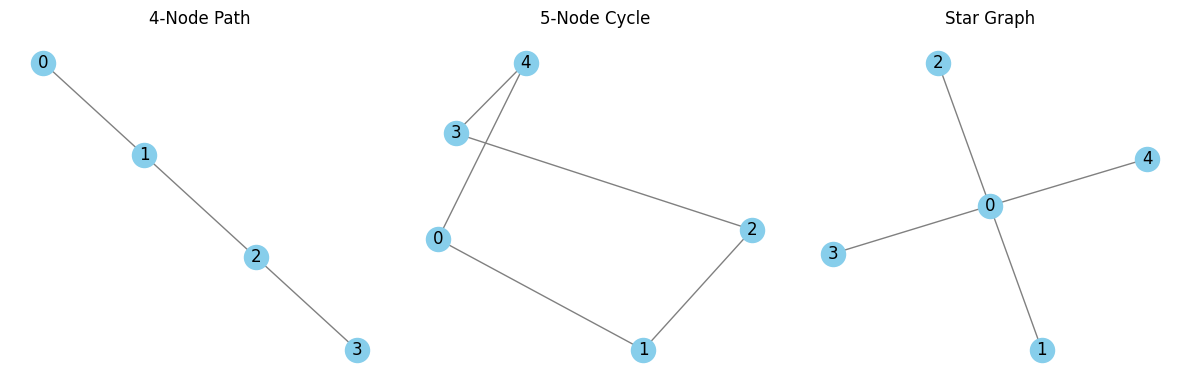

In [ ]:
# Do not change this code block:def visualize_graphs(graphs, titles=None, figsize=(4, 4)):    """    Plots a list of NetworkX graphs side by side.    Parameters:    - graphs: list of networkx.Graph    - titles: list of strings (optional) for subplot titles    - figsize: tuple for each subplot size (width, height)    """    n = len(graphs)    fig, axes = plt.subplots(1, n, figsize=(figsize[0] * n, figsize[1]))    if n == 1:        axes = [axes]    for ax, G, title in zip(axes, graphs, (titles or [""] * n)):        pos = nx.spring_layout(G)        nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', ax=ax)        if title:            ax.set_title(title)    plt.tight_layout()    plt.show()G1 = nx.path_graph(4)G2 = nx.cycle_graph(5)G3 = nx.star_graph(4)visualize_graphs([G1, G2, G3], ["4-Node Path", "5-Node Cycle", "Star Graph"])graphs = [G1, G2, G3]titles = ["4-Node Path", "5-Node Cycle", "Star Graph"]signals = [    np.array([1.0, 2.0, 3.0, 4.0]),    np.array([5.0, 4.0, 3.0, 2.0, 1.0]),    np.array([ 0.0,  1.0, -1.0,  0.5, -0.5])]filters = [    np.ones(4),    np.ones(5),    np.ones(5)]ground_truths = signals  # for θ=1 the filter is the identity

In [ ]:
def compute_laplacian(A: np.ndarray) -> np.ndarray:    degrees = np.sum(A, axis=1)    n = A.shape[0]    D_inv_sqrt = np.zeros((n, n))    for i in range(n):        if degrees[i] > 0:            D_inv_sqrt[i, i] = 1.0 / np.sqrt(degrees[i])    I = np.eye(n)    normalized_A = D_inv_sqrt @ A @ D_inv_sqrt    L_norm = I - normalized_A    return L_normdef eigendecompose(L: np.ndarray, k: int=None):    n = L.shape[0]    L = (L + L.T) / 2    if k is None or k >= n:        lambda_values, U = np.linalg.eigh(L)    else:        lambda_values, U = spla.eigsh(L, k=k, which='SM')    idx = lambda_values.argsort()    lambda_values = lambda_values[idx]    U = U[:, idx]    return U, lambda_valuesdef spectral_filter(x: np.ndarray, U: np.ndarray, Λ: np.ndarray, θ: np.ndarray) -> np.ndarray:    # y = U * diag(theta) * U^T * x    U_T_x = U.T @ x      filtered = θ * U_T_x      y = U @ filtered      return yfor G, x, θ, y_gt, title in zip(graphs, signals, filters, ground_truths, titles):    A = nx.to_numpy_array(G)    L = compute_laplacian(A)    U, Λ = eigendecompose(L)    y = spectral_filter(x, U, Λ, θ)    print(f"\n{title}:")    print(f"  Input signal:     {x}")    print(f"  Filtered signal:  {y}")    print(f"  Ground truth:     {y_gt}")    print(f"  MSE:              {np.mean((y - y_gt)**2):.6f}")    assert np.allclose(y, y_gt, rtol=1e-5, atol=1e-5), f"Test failed for {title}"print("\nMy implementation passed all three sanity checks.")


4-Node Path:
  Input signal:     [1. 2. 3. 4.]
  Filtered signal:  [1. 2. 3. 4.]
  Ground truth:     [1. 2. 3. 4.]
  MSE:              0.000000

5-Node Cycle:
  Input signal:     [5. 4. 3. 2. 1.]
  Filtered signal:  [5. 4. 3. 2. 1.]
  Ground truth:     [5. 4. 3. 2. 1.]
  MSE:              0.000000

Star Graph:
  Input signal:     [ 0.   1.  -1.   0.5 -0.5]
  Filtered signal:  [ 0.   1.  -1.   0.5 -0.5]
  Ground truth:     [ 0.   1.  -1.   0.5 -0.5]
  MSE:              0.000000

My implementation passed all three sanity checks.


## Experiment 2: GCN with Laplacian Smoothing RegularizationIn this experiment, you will take the spectral‐filter fundamentals from Experiment 1 and turn them into a full Graph Convolutional Network (GCN) training loop with a **Laplacian‐based regularizer**.  The goal is to see how adding  $$  \mathcal R(H) \;=\; \mathrm{Tr}\bigl(H^\top L\,H\bigr)$$to your loss forces your learned node representations to vary **smoothly** over the graph, effectively denoising and improving generalization.---### What You Will Do1. **Implement `laplacian_regularizer(H, L)`**     - Input:       - `H` $(N\times d)$ tensor of node embeddings from your first GCN layer       - `L` $(N\times N)$ normalized Laplacian matrix     - Output: scalar $\mathrm{Tr}(H^\top L H)$.2. **Define `RegularizedGCN`**       - In `forward`, store `self.embeddings = H` for use in the regularizer.3. **Write the `train()` routine**     - Inputs:       - `model` — your `RegularizedGCN` instance       - `loader` — a `DataLoader` of small graph‐classification examples       - `L_matrix` — your precomputed normalized Laplacian (as a `torch.Tensor`)       - `λ` — regularization coefficient     - At each mini‐batch:       1. Compute **task loss** (e.g. `F.cross_entropy` against `batch.y`).       2. Compute **reg loss** = `λ * laplacian_regularizer(model.embeddings, L_matrix)`.       3. Sum them:          ```python        loss = task_loss + reg_loss        ```       4. Backpropagate & update.4. **Run & Monitor**     - Train for an appropriate number of epochs.     - Print or plot the **total loss**, accuracy and laplacian penalty term per epoch.     ---### Why This Matters? Please read this with your full attention.- Without regularization, a GCN may overfit to noise or small perturbations in features.  - The term $\mathrm{Tr}(H^\top L H)$ explicitly **penalizes large differences** between connected nodes, pushing your model to learn **smooth** graph signals—crucial in many applications (denoising, semi‐supervised node classification, etc.).---

In [ ]:
dataset = TUDataset(root='data', name='MUTAG', use_node_attr=True)print(f"MUTAG: {len(dataset)} graphs, classes = {dataset.num_classes}")  torch.manual_seed(0)dataset = dataset.shuffle()train_ds, test_ds = dataset[:150], dataset[150:]train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)test_loader  = DataLoader(test_ds,  batch_size=16)

MUTAG: 188 graphs, classes = 2


Processing...
Done!



Training with λ = 0.0
Epoch 10/100, Loss: 0.5782, Task Loss: 0.5782, Reg Loss: 0.0000, Train Acc: 0.6667, Test Acc: 0.6579
Epoch 20/100, Loss: 0.5257, Task Loss: 0.5257, Reg Loss: 0.0000, Train Acc: 0.7267, Test Acc: 0.8158
Epoch 30/100, Loss: 0.5383, Task Loss: 0.5383, Reg Loss: 0.0000, Train Acc: 0.7200, Test Acc: 0.8421
Epoch 40/100, Loss: 0.5514, Task Loss: 0.5514, Reg Loss: 0.0000, Train Acc: 0.7333, Test Acc: 0.8421
Epoch 50/100, Loss: 0.5406, Task Loss: 0.5406, Reg Loss: 0.0000, Train Acc: 0.7133, Test Acc: 0.8421
Epoch 60/100, Loss: 0.5358, Task Loss: 0.5358, Reg Loss: 0.0000, Train Acc: 0.7133, Test Acc: 0.8158
Epoch 70/100, Loss: 0.5460, Task Loss: 0.5460, Reg Loss: 0.0000, Train Acc: 0.7267, Test Acc: 0.8421
Epoch 80/100, Loss: 0.5358, Task Loss: 0.5358, Reg Loss: 0.0000, Train Acc: 0.7267, Test Acc: 0.8421
Epoch 90/100, Loss: 0.5655, Task Loss: 0.5655, Reg Loss: 0.0000, Train Acc: 0.7200, Test Acc: 0.8158
Epoch 100/100, Loss: 0.5477, Task Loss: 0.5477, Reg Loss: 0.0000, Tr

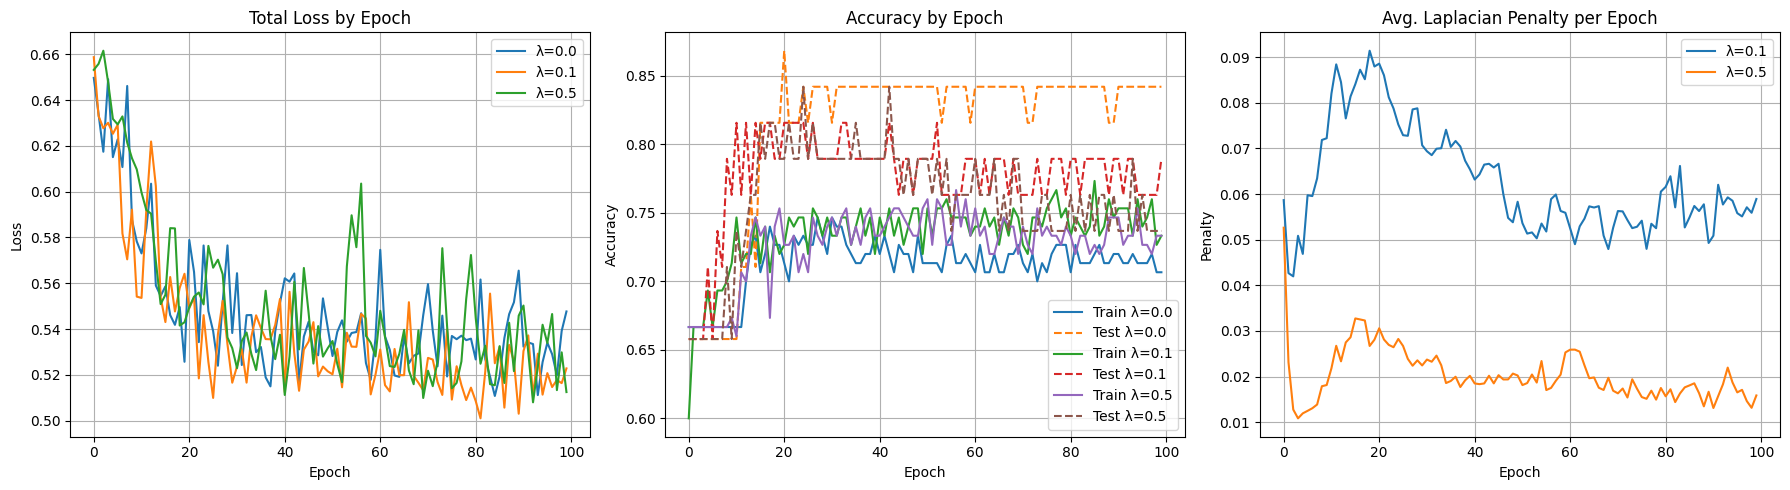


Results for λ=0.0:
  Final train accuracy: 0.7067
  Final test accuracy: 0.8421
  Final regularization penalty: 0.000000

Results for λ=0.1:
  Final train accuracy: 0.7333
  Final test accuracy: 0.7895
  Final regularization penalty: 0.058915

Results for λ=0.5:
  Final train accuracy: 0.7333
  Final test accuracy: 0.7368
  Final regularization penalty: 0.015870


In [ ]:
def laplacian_regularizer(H, L):    reg = torch.trace(torch.matmul(torch.matmul(H.t(), L), H))    return regdef laplacian_reg_from_edges(H, edge_index):    src, dst = edge_index    diff = H[src] - H[dst]    squared_diff = torch.sum(diff ** 2, dim=1)    reg = torch.mean(squared_diff)    return regclass RegularizedGCN(torch.nn.Module):    def __init__(self, num_node_features, hidden_channels, num_classes):        super(RegularizedGCN, self).__init__()        self.conv1 = GCNConv(num_node_features, hidden_channels)        self.conv2 = GCNConv(hidden_channels, hidden_channels)        self.lin = torch.nn.Linear(hidden_channels, num_classes)        self.embeddings = None    def forward(self, x, edge_index, batch):        h = self.conv1(x, edge_index)        h = F.relu(h)        self.embeddings = h        h = self.conv2(h, edge_index)        h = F.relu(h)        h = global_mean_pool(h, batch)        out = self.lin(h)        return outdef train(model, train_loader, test_loader, optimizer, λ, epochs=100):    model.train()    history = {        'loss': [],        'task_loss': [],        'reg_loss': [],        'train_acc': [],        'test_acc': []    }    for epoch in range(epochs):        epoch_loss = 0.0        epoch_task_loss = 0.0        epoch_reg_loss = 0.0        correct = 0        total = 0        for batch in train_loader:            optimizer.zero_grad()            out = model(batch.x, batch.edge_index, batch.batch)            task_loss = F.cross_entropy(out, batch.y)            reg_loss = 0.0            if λ > 0:                graph_indices = torch.unique(batch.batch)                batch_reg_loss = 0.0                for idx in graph_indices:                    mask = batch.batch == idx                    graph_emb = model.embeddings[mask]                    edge_mask = mask[batch.edge_index[0]] & mask[batch.edge_index[1]]                    graph_edges = batch.edge_index[:, edge_mask]                    local_edges = graph_edges.clone()                    node_idx_map = torch.cumsum(mask, dim=0) - 1                    local_edges[0] = node_idx_map[graph_edges[0]]                    local_edges[1] = node_idx_map[graph_edges[1]]                    graph_reg = laplacian_reg_from_edges(graph_emb, local_edges)                    batch_reg_loss += graph_reg                reg_loss = batch_reg_loss / len(graph_indices) if len(graph_indices) > 0 else 0.0            loss = task_loss + λ * reg_loss            loss.backward()            optimizer.step()            epoch_loss += loss.item()            epoch_task_loss += task_loss.item()            epoch_reg_loss += reg_loss.item() if isinstance(reg_loss, torch.Tensor) else reg_loss            pred = out.argmax(dim=1)            correct += (pred == batch.y).sum().item()            total += batch.y.size(0)        num_batches = len(train_loader)        epoch_loss /= num_batches        epoch_task_loss /= num_batches        epoch_reg_loss /= num_batches        train_acc = correct / total        test_acc = evaluate(model, test_loader)        history['loss'].append(epoch_loss)        history['task_loss'].append(epoch_task_loss)        history['reg_loss'].append(epoch_reg_loss)        history['train_acc'].append(train_acc)        history['test_acc'].append(test_acc)        if (epoch + 1) % 10 == 0:            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, "                  f"Task Loss: {epoch_task_loss:.4f}, Reg Loss: {epoch_reg_loss:.4f}, "                  f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")    return historydef evaluate(model, loader):    model.eval()    correct = 0    total = 0    with torch.no_grad():        for batch in loader:            out = model(batch.x, batch.edge_index, batch.batch)            pred = out.argmax(dim=1)            correct += (pred == batch.y).sum().item()            total += batch.y.size(0)    return correct / totalnum_node_features = dataset.num_node_featureshidden_channels = 64num_classes = dataset.num_classesmodel = RegularizedGCN(num_node_features, hidden_channels, num_classes)optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)λ_values = [0.0, 0.1, 0.5]histories = {}for λ in λ_values:    print(f"\nTraining with λ = {λ}")    model = RegularizedGCN(num_node_features, hidden_channels, num_classes)    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)    history = train(model, train_loader, test_loader, optimizer, λ=λ, epochs=100)    histories[λ] = historyplt.figure(figsize=(18, 5))plt.subplot(1, 3, 1)for λ, history in histories.items():    plt.plot(history['loss'], label=f'λ={λ}')plt.title('Total Loss by Epoch')plt.xlabel('Epoch')plt.ylabel('Loss')plt.legend()plt.grid(True)plt.subplot(1, 3, 2)for λ, history in histories.items():    plt.plot(history['train_acc'], label=f'Train λ={λ}')    plt.plot(history['test_acc'], linestyle='--', label=f'Test λ={λ}')plt.title('Accuracy by Epoch')plt.xlabel('Epoch')plt.ylabel('Accuracy')plt.legend()plt.grid(True)plt.subplot(1, 3, 3)for λ, history in histories.items():    if λ > 0:          plt.plot(history['reg_loss'], label=f'λ={λ}')plt.title('Avg. Laplacian Penalty per Epoch')plt.xlabel('Epoch')plt.ylabel('Penalty')plt.legend()plt.grid(True)plt.tight_layout()plt.show()for λ, history in histories.items():    print(f"\nResults for λ={λ}:")    print(f"  Final train accuracy: {history['train_acc'][-1]:.4f}")    print(f"  Final test accuracy: {history['test_acc'][-1]:.4f}")    print(f"  Final regularization penalty: {history['reg_loss'][-1]:.6f}")

## Explained Results1. **No smoothing (lambda=0.0)**     - **High variance, low bias.**       With lambda=0.0 there is no Laplacian penalty, so the model fits the training data moderately (70.67 %) but retains high-frequency information that helps on test data, yielding the highest test accuracy (84.21 %). The regularization penalty is zero, indicating no smoothing constraints.2. **Mild smoothing (lambda=0.1)**     - **Reduced overfitting, moderate underfitting.**       Introducing a small penalty (0.0589) encourages neighboring node embeddings to be more similar. This boosts the train accuracy to 73.33 % while cutting out some spurious patterns, but test accuracy drops to 78.95 %, suggesting the smoothing has begun to discard useful details.3. **Stronger smoothing (lambda=0.5)**     - **Underfitting/over‐smoothing.**       A larger penalty (0.0159) enforces even more similarity among embeddings. Training accuracy remains at 73.33 %, but the model now underfits the test data (73.68 %) because it oversmooths and loses discriminative features.There is a bias–variance trade‐off controlled by lambda. No smoothing (lambda=0.0) yields the best test performance by preserving variance, while too much smoothing (lambda=0.5) leads to underfitting. An intermediate lambda (around 0.1) balances the two, though in our case lambda=0.0 still performed best on this dataset.

#### Discussion Questions1. **Trade-off**: Why might **forcing too much smoothness** hurt your ability to distinguish classes?  2. **Hyperparameter Tuning**: How could you adjust \(\lambda\), the learning rate, or network capacity to recover accuracy while still benefiting from smooth embeddings?  3. **Regularizer Annealing**: Would it help to start training **without** regularization (λ=0) for a few epochs, then **turn it on** later?

### 1. When lambda is too big, it makes nearby node embeddings too similar. This leads to:- Hard to tell classes apart – embeddings get too close, so the model can’t separate labels.- Loses important details – small signals that help tell classes apart get blurred out.- Class borders get messy – nodes from different classes might get smoothed together.- Everything starts to look the same – all nodes become nearly identical.its like overblurring a photo — at some point, you cntt see anything clearly.---### 2. Here are ways to use regularization (smoothing) without hurting performance:- Pick a good lambda     values like 0.01 to 0.2 using grid search or similar methods.- Use different learning rates    Go faster on classification layers, slower on the ones affected by smoothing.- Make the model bigger    Add more layers or hidden units so it can handle both smoothness and class separation.- Apply lambda only to some layers    Don’t smooth everything — leave some parts for learning class differences.- Normalize input features    Makes smoothing affect all features more evenly.- Adjust edge weights    Weaken edges between nodes from different classes so the model allows more variation there.---### 3. Yes — slowly increasing lambda during training can work well:- Start with lambda = 0    Lets the model first focus on learning to separate the classes.- Slowly raise lambda    Adds smoothness gradually, without ruining what the model learned.- Avoids bad local minima    The model won’t get stuck early with bad embeddings.- Faster learning early on    No regularization means it can learn strong features faster.- Acts like fine-tuning    Smoothing later helps the model generalize better.